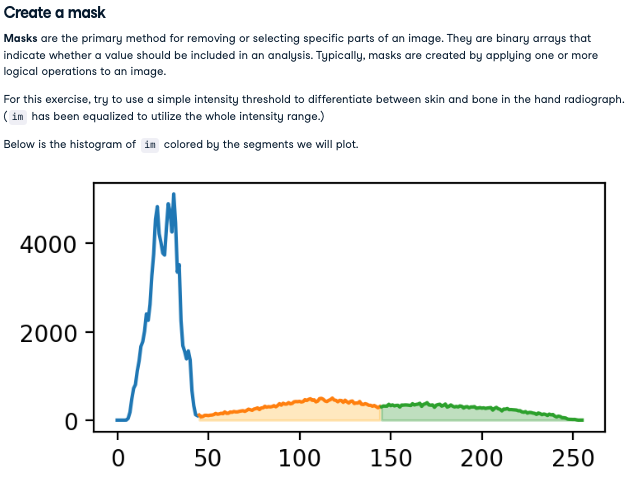

- Create a bone mask by selecting pixels with intensities greater than or equal to 145.
- Create a skin mask by selecting pixels with intensities greater than or equal to 45 and less than 145.
- "Plot the skin and bone masks in grayscale.

In [ ]:
# Create skin and bone masks
mask_bone = im >= 145
mask_skin = (im >= 45) & (im <145)

# Plot the skin (0) and bone (1) masks
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_skin, cmap='gray')
axes[1].imshow(mask_bone, cmap='gray')
format_and_render_plot()

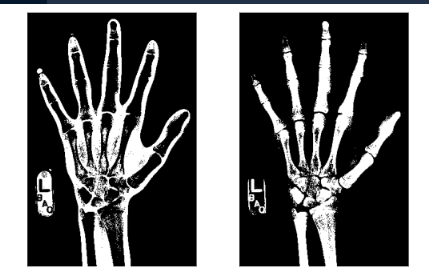

## Apply a mask
Although masks are binary, they can be applied to images to filter out pixels where the mask is False.

NumPy's where() function is a flexible way of applying masks. It takes three arguments:

np.where(condition, x, y)
condition, x and y can be either arrays or single values. This allows you to pass through original image values while setting masked values to 0.

Let's practice applying masks by selecting the bone-like pixels from the hand x-ray (im).

- Create a Boolean bone mask by selecting pixels greater than or equal to 145.
- Apply the mask to your image using np.where(). Values not in the mask should be set to 0.
- Create a histogram of the masked image. Use the following arguments to select only non-zero pixels: min=1, max=255, bins=255.
- Plot the masked image and the histogram. This has been done for you.

In [ ]:
# Import SciPy's "ndimage" module
import scipy.ndimage  as ndi

# Screen out non-bone pixels from "im"
mask_bone = im >= 145
im_bone = np.where(mask_bone, im, 0)

# Get the histogram of bone intensities
hist = ndi.histogram(im_bone, 1, 255, bins=255)

# Plot masked image and histogram
fig, axes = plt.subplots(2,1)
axes[0].imshow(im_bone)
axes[1].plot(hist)
format_and_render_plot()

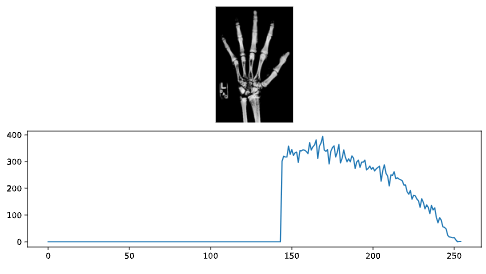

## Tune a mask
Imperfect masks can be tuned through the addition and subtraction of pixels. SciPy includes several useful methods for accomplishing these ends. These include:

binary_dilation: Add pixels along edges
binary_erosion: Remove pixels along edges
binary_opening: Erode then dilate, "opening" areas near edges
binary_closing: Dilate then erode, "filling in" holes
For this exercise, create a bone mask then tune it to include additional pixels.

For the remaining exercises, we have run the following import for you:

import scipy.ndimage as ndi

- Create a bone by selecting pixels from im that are greater than or equal to 145.
- Use ndi.binary_dilation() to increase the size of mask_bone. Set the number of iterations to 5 to perform the dilation multiple times.
- Use ndi.binary_closing() to fill in holes in mask_bone. Set the number of iterations to 5 to holes up to 10 pixels wide.
- Plot the original and tuned masks.



In [ ]:
# Create and tune bone mask
mask_bone = im >= 145
mask_dilate = ndi.binary_dilation(mask_bone, iterations=5)
mask_closed = ndi.binary_closing(mask_bone, iterations=5)

# Plot masked images
fig, axes = plt.subplots(1,3)
axes[0].imshow(mask_bone)
axes[1].imshow(mask_dilate)
axes[2].imshow(mask_closed)
format_and_render_plot()

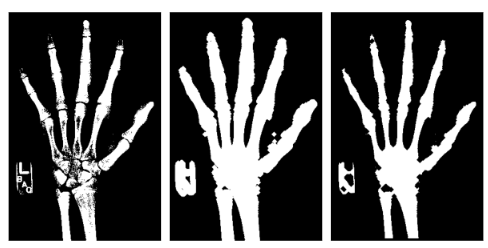